In [1]:
# Cell 1: Imports and data load
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load CSV (ensure the file is in the working directory)
df = pd.read_csv("D:\\DS Assignment\\MLR\\MLR\\ToyotaCorolla - MLR.csv")
df_orig = df.copy()  # keep original copy
df.head()


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
# Cell 2: Basic structure and missing values (fixed)
from IPython.display import display  # optional but safe

print(df.shape)
print(df.columns.tolist())
df.info()  # print already returns None, no need to wrap in print()

# Option A: numeric-only describe (recommended)
display(df.describe(include=[np.number]).T)

# Option B: via select_dtypes (alternative)
# display(df.select_dtypes(include='number').describe().T)

# Missing values per column
display(df.isna().sum())


(1436, 11)
['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


,count,mean,std,min,25%,50%,75%,max
Price,1436.0,10730.824513,3626.964585,4350.0,8450.0,9900.0,11950.00,32500.0
Age_08_04,1436.0,55.947075,18.599988,1.0,44.0,61.0,70.00,80.0
KM,1436.0,68533.259749,37506.448872,1.0,43000.0,63389.5,87020.75,243000.0
HP,1436.0,101.502089,14.981080,69.0,90.0,110.0,110.00,192.0
Automatic,1436.0,0.055710,0.229441,0.0,0.0,0.0,0.00,1.0
cc,1436.0,1576.855850,424.386770,1300.0,1400.0,1600.0,1600.00,16000.0
Doors,1436.0,4.033426,0.952677,2.0,3.0,4.0,5.00,5.0
Cylinders,1436.0,4.000000,0.000000,4.0,4.0,4.0,4.00,4.0
Gears,1436.0,5.026462,0.188510,3.0,5.0,5.0,5.00,6.0
Weight,1436.0,1072.459610,52.641120,1000.0,1040.0,1070.0,1085.00,1615.0


Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [4]:
# Cell 3: Clean column names and align with assignment semantics
df.columns = [c.strip().replace(' ', '_') for c in df.columns]

# Try to align a few names
rename_map = {
    'Age_08_04': 'Age',   # age proxy
    'Fuel_Type': 'FuelType',
    'cc': 'CC'
}
for k, v in rename_map.items():
    if k in df.columns:
        df.rename(columns={k: v}, inplace=True)

# Basic sanity checks: remove perfect duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Optional: handle clearly impossible CC values (e.g., > 6000 cc) by marking as NaN
if 'CC' in df.columns:
    df.loc[df['CC'] > 6000, 'CC'] = np.nan

# If any column like Cylinders/Gears is mostly constant or not required, we can keep for now and let VIF decide later
df.head()


,Price,Age,KM,FuelType,HP,Automatic,CC,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000.0,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000.0,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000.0,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000.0,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000.0,3,4,5,1170


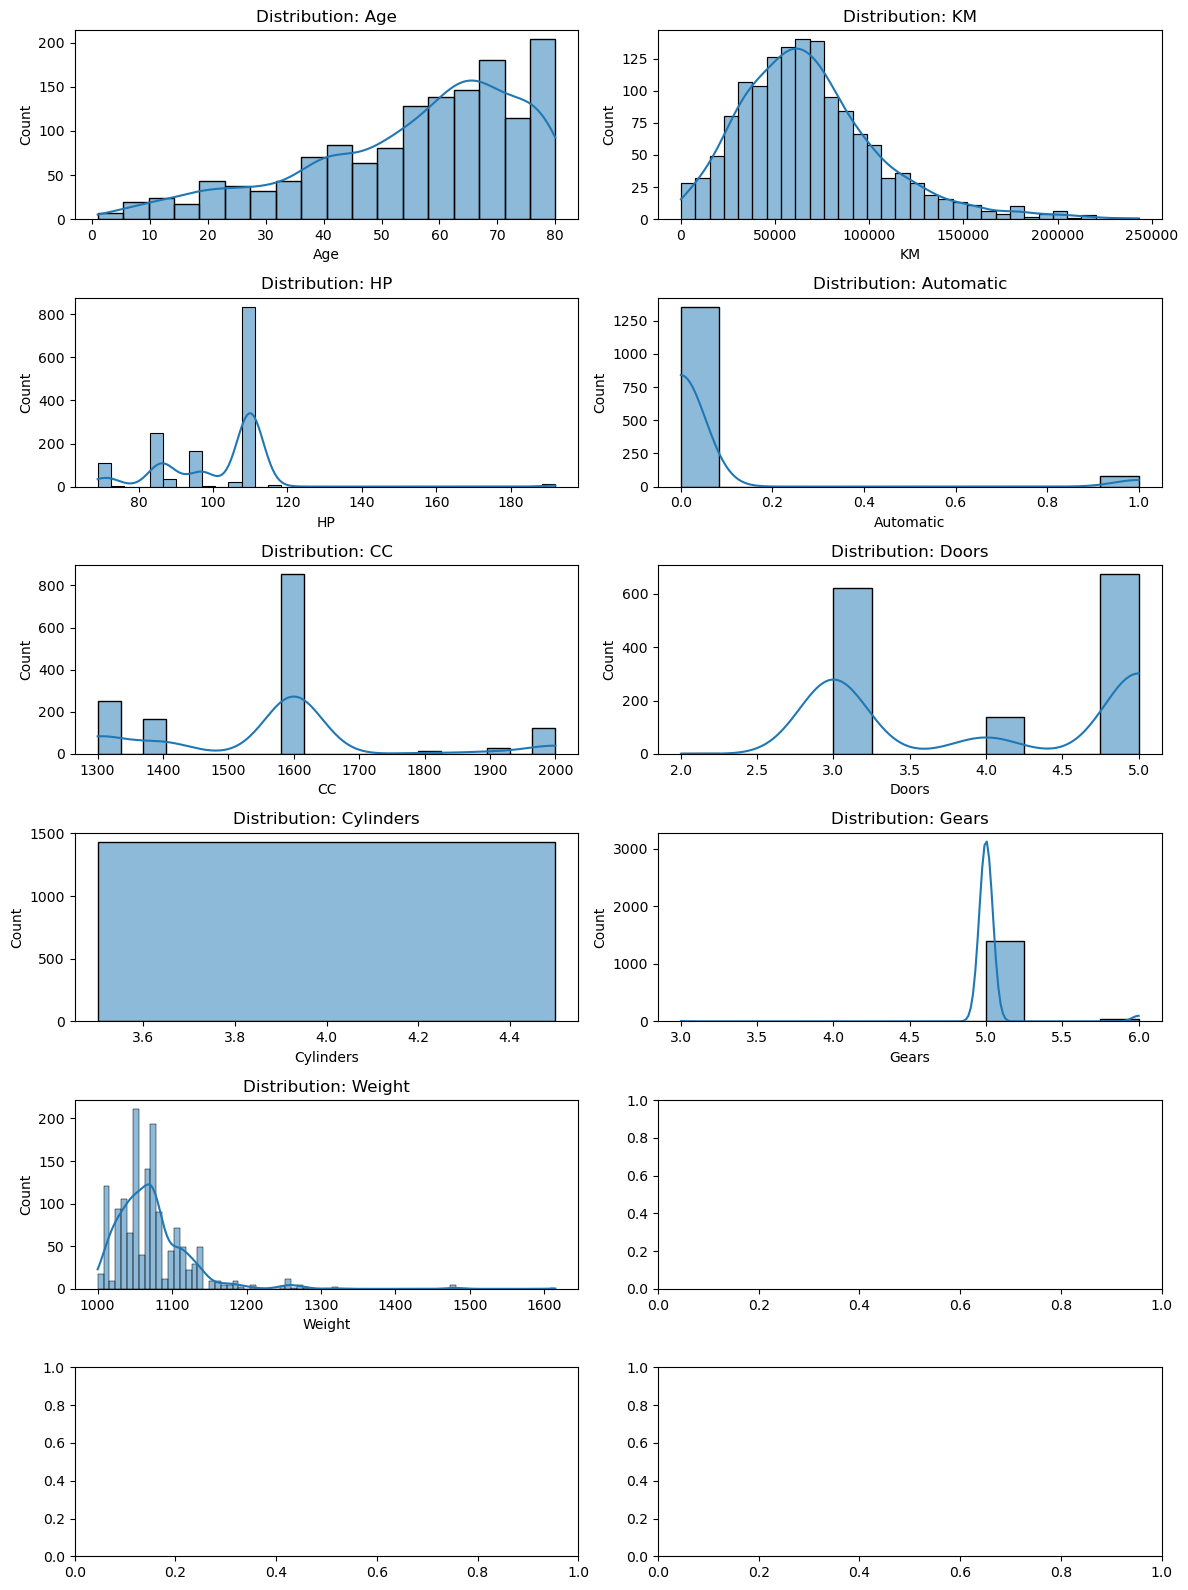

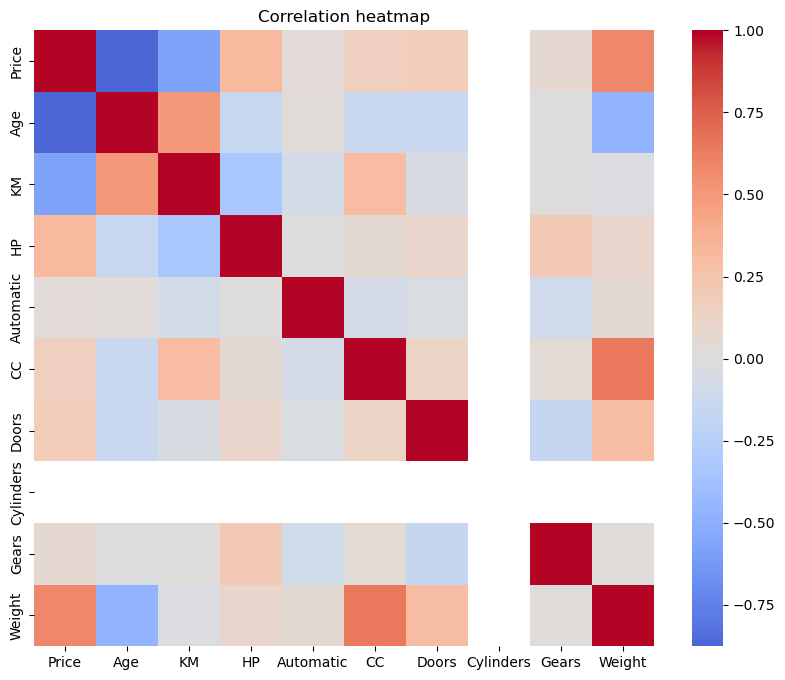

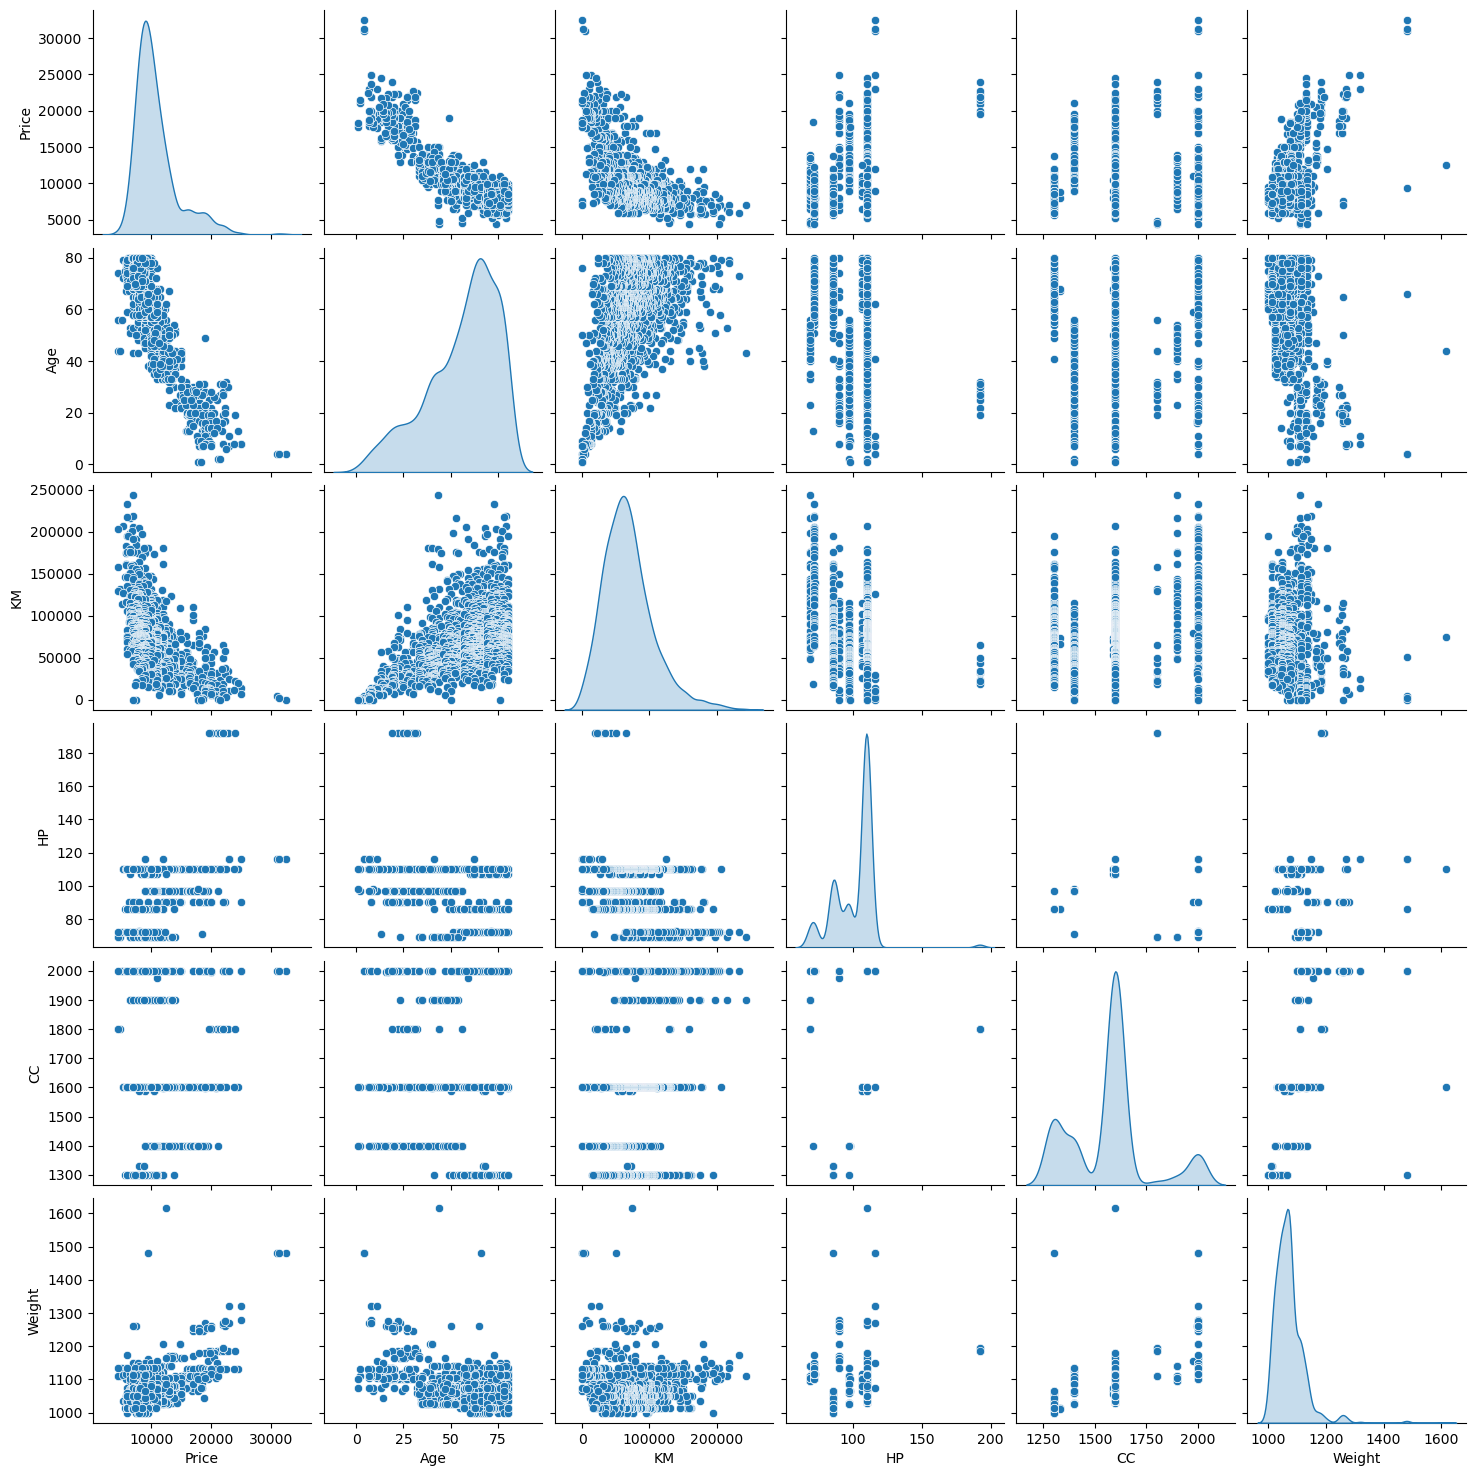

In [5]:
# Cell 4: Target distribution and correlations
target = 'Price'

# Univariate distributions for a few key numeric features
num_cols = [c for c in df.columns if df[c].dtype != 'object' and c != target]
fig, axes = plt.subplots(nrows=min(6, len(num_cols)), ncols=2, figsize=(12, 16))
axes = axes.flatten()

for i, c in enumerate(num_cols[:len(axes)]):
    sns.histplot(df[c].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution: {c}')
plt.tight_layout()
plt.show()

# Correlation heatmap (numeric only)
plt.figure(figsize=(10, 8))
corr = df[[target] + num_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.show()

# Price vs some key drivers
key_drivers = [col for col in ['Age','KM','HP','CC','Weight'] if col in df.columns]
sns.pairplot(df[[target] + key_drivers].dropna(), diag_kind='kde')
plt.show()


In [6]:
# Cell 5: Define features and basic transformers
target = 'Price'
assert target in df.columns, "Price column must exist"

# Identify categorical and numeric columns
cat_cols = [c for c in df.columns if df[c].dtype == 'object']
num_cols = [c for c in df.columns if df[c].dtype != 'object' and c != target]

# Remove rows with missing target
df = df[~df[target].isna()].copy()

# Simple missing handling: drop rows with too many missing in key numeric columns
# Alternatively, you can impute; here we drop for simplicity on a small subset
key_num = [c for c in ['Age','KM','HP','CC','Doors','Weight'] if c in num_cols]
df = df.dropna(subset=key_num)

X = df[cat_cols + num_cols]
y = df[target].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ColumnTransformer: One-hot encode categoricals, pass-through numerics
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)


In [7]:
# Cell 6: Baseline Linear Regression with scikit-learn
baseline_model = Pipeline(steps=[
    ('prep', preprocess),
    ('lin', LinearRegression())
])
baseline_model.fit(X_train, y_train)

y_pred_tr = baseline_model.predict(X_train)
y_pred_te = baseline_model.predict(X_test)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Model 1 (Baseline) metrics:")
print("Train R2:", r2_score(y_train, y_pred_tr))
print("Test  R2:", r2_score(y_test, y_pred_te))
print("Test RMSE:", rmse(y_test, y_pred_te))
print("Test MAE:", mean_absolute_error(y_test, y_pred_te))


Model 1 (Baseline) metrics:
Train R2: 0.8710188888790964
Test  R2: 0.8514329917034804
Test RMSE: 1274.1876138697612
Test MAE: 951.702899586502


In [9]:
# Cell 7 (fixed): Coefficient interpretation with statsmodels OLS

import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1) Ensure the same X and y as earlier, but keep y as a Series (with index)
y_series = df[target].astype(float)  # keep index for alignment

# 2) One-hot encode categoricals
Xd = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# 3) Align X and y by index, drop missing safely
data_ols = Xd.join(y_series, how='inner')
data_ols = data_ols.apply(pd.to_numeric, errors='coerce')  # force all numeric
data_ols = data_ols.dropna(axis=0)  # drop any remaining NaNs

# 4) Split endog/exog and add constant
endog = data_ols[target].astype(float)
exog = data_ols.drop(columns=[target])

exog = sm.add_constant(exog, has_constant='add')  # ensure intercept

# 5) Cast to float arrays (defensive) and fit
exog_arr = exog.to_numpy(dtype=float)
endog_arr = endog.to_numpy(dtype=float)

ols_model = sm.OLS(endog_arr, exog_arr).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     936.6
Date:                Sat, 04 Oct 2025   Prob (F-statistic):               0.00
Time:                        00:03:49   Log-Likelihood:                -12326.
No. Observations:                1434   AIC:                         2.467e+04
Df Residuals:                    1423   BIC:                         2.473e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -350.1591     93.642     -3.739      0.0

In [11]:
# Cell 8 (fixed): Robust VIF computation
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Prefer using the cleaned/joined design from Cell 7
# If you have 'data_ols' from Cell 7 (Xd + target aligned), reuse it:
# data_ols = Xd.join(y_series, how='inner').apply(pd.to_numeric, errors='coerce').dropna()

# Features only for VIF
X_vif = data_ols.drop(columns=[target]).copy()

# 1) Force numeric dtypes and remove non-finite rows
X_vif = X_vif.apply(pd.to_numeric, errors='coerce')
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

# 2) Drop near-constant columns (optional but safer for auxiliary OLS)
const_like = [c for c in X_vif.columns if X_vif[c].nunique() <= 1]
if const_like:
    X_vif = X_vif.drop(columns=const_like)

# 3) Add constant for regression context; we'll skip it when computing VIF
X_vif_const = sm.add_constant(X_vif, has_constant='add')

# 4) Convert to float ndarray for statsmodels
exog = X_vif_const.to_numpy(dtype=float)

# 5) Compute VIFs, skipping the intercept
features = X_vif_const.columns
vifs = []
for i, col in enumerate(features):
    if col == 'const':
        vifs.append(np.nan)  # skip constant in report
    else:
        vifs.append(variance_inflation_factor(exog, i))

vif_df = pd.DataFrame({'feature': features, 'VIF': vifs}).dropna().sort_values('VIF', ascending=False)
display(vif_df.head(15))


,feature,VIF
9,FuelType_Diesel,21.846064
10,FuelType_Petrol,9.666669
5,CC,8.760334
3,HP,6.459400
8,Weight,3.277428
2,KM,2.019913
1,Age,1.924094
6,Doors,1.240530
7,Gears,1.129405
4,Automatic,1.083824


In [12]:
# Cell 9: Drop high-VIF features and refit
high_vif_features = vif_df.loc[vif_df["VIF"] > 5, "feature"].tolist()

# Avoid dropping the intercept/constant if present
high_vif_features = [f for f in high_vif_features if f != 'const']

Xd_vif = Xd.drop(columns=list(set(high_vif_features)), errors='ignore')
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    Xd_vif, y_aligned, test_size=0.2, random_state=42
)

lin2 = LinearRegression()
lin2.fit(X_train_v, y_train_v)

y_pred_tr2 = lin2.predict(X_train_v)
y_pred_te2 = lin2.predict(X_test_v)

print("Model 2 (VIF-filtered) metrics:")
print("Train R2:", r2_score(y_train_v, y_pred_tr2))
print("Test  R2:", r2_score(y_test_v, y_pred_te2))
print("Test RMSE:", rmse(y_test_v, y_pred_te2))
print("Test MAE:", mean_absolute_error(y_test_v, y_pred_te2))


Model 2 (VIF-filtered) metrics:
Train R2: 0.8534695237760348
Test  R2: 0.8327599873115695
Test RMSE: 1351.8928962423984
Test MAE: 986.5836920416865


In [13]:
# Cell 10: Polynomial interactions on select numerics
base_num = [c for c in ['Age','KM','HP','CC','Weight'] if c in num_cols]
poly = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('poly', Pipeline([
            ('sel', 'passthrough')  # no selector; ColumnTransformer handles it
        ]), base_num),
        ('num_rest', 'passthrough', [c for c in num_cols if c not in base_num])
    ],
    remainder='drop'
)

# Wrap poly features with PolynomialFeatures for selected numerics only
model3 = Pipeline(steps=[
    ('prep', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('poly', Pipeline([
            ('pf', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True))
        ]), base_num),
        ('num_rest', 'passthrough', [c for c in num_cols if c not in base_num])
    ])),
    ('lin', LinearRegression())
])

model3.fit(X_train, y_train)
y_pred_tr3 = model3.predict(X_train)
y_pred_te3 = model3.predict(X_test)

print("Model 3 (Interactions) metrics:")
print("Train R2:", r2_score(y_train, y_pred_tr3))
print("Test  R2:", r2_score(y_test, y_pred_te3))
print("Test RMSE:", rmse(y_test, y_pred_te3))
print("Test MAE:", mean_absolute_error(y_test, y_pred_te3))


Model 3 (Interactions) metrics:
Train R2: 0.9027985860104234
Test  R2: 0.8853312691448807
Test RMSE: 1119.4242041147977
Test MAE: 835.8911381593197


In [14]:
# Cell 11: Ridge and Lasso with scaling and CV over alpha
alphas = np.logspace(-3, 3, 25)

reg_prep = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

ridge_model = Pipeline(steps=[
    ('prep', reg_prep),
    ('ridge', RidgeCV(alphas=alphas, cv=5))
])
ridge_model.fit(X_train, y_train)
y_pred_te_r = ridge_model.predict(X_test)

lasso_model = Pipeline(steps=[
    ('prep', reg_prep),
    ('lasso', LassoCV(alphas=alphas, cv=5, max_iter=10000))
])
lasso_model.fit(X_train, y_train)
y_pred_te_l = lasso_model.predict(X_test)

print("Ridge best alpha:", ridge_model.named_steps['ridge'].alpha_)
print("Lasso best alpha:", lasso_model.named_steps['lasso'].alpha_)

print("Ridge  Test R2:", r2_score(y_test, y_pred_te_r), "RMSE:", rmse(y_test, y_pred_te_r))
print("Lasso  Test R2:", r2_score(y_test, y_pred_te_l), "RMSE:", rmse(y_test, y_pred_te_l))


Ridge best alpha: 0.001
Lasso best alpha: 0.001
Ridge  Test R2: 0.8514346236625934 RMSE: 1274.1806155872273
Lasso  Test R2: 0.8514337542089663 RMSE: 1274.1843440445712
